# TASK 01 — A Backward Pass by Hand

**Goal:** Trace derivatives backward through a tiny neural-network-style computation.

We will use:

- `x = 3.0`
- `w = 1.0`
- `target = 12.0`

The computation is:

\[
a = wx
\]

\[
L = (a-target)^2
\]

We will:
1. Do the forward pass.
2. Derive the gradient by hand using the chain rule.
3. Verify the gradient numerically.
4. Take one gradient-descent update.
5. Plot the loss before and after the update.


## 1. Forward Pass

First calculate the prediction:

\[
a = wx
\]

With `w = 1` and `x = 3`:

\[
a = 1	imes3 = 3
\]

Now calculate the squared-error loss:

\[
L=(a-target)^2
\]

\[
L=(3-12)^2=81
\]

So the model currently predicts **3**, while the target is **12**, giving a loss of **81**.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

x, w, target = 3.0, 1.0, 12.0

# Forward pass
a = w * x
loss = (a - target) ** 2

print(f"Prediction (a): {a}")
print(f"Loss: {loss}")


Prediction (a): 3.0
Loss: 81.0


## 2. Backward Pass — Derivatives by Hand

We start with:

\[
L=(a-target)^2
\]

### Step 1: Find `dL/da`

Differentiate the loss with respect to `a`:

\[

rac{dL}{da}=2(a-target)
\]

For our values:

\[

rac{dL}{da}=2(3-12)=-18
\]

### Step 2: Find `da/dw`

Because:

\[
a=wx
\]

and `x` is constant:

\[

rac{da}{dw}=x=3
\]

### Step 3: Chain them together

The chain rule says:

\[

rac{dL}{dw}
=

rac{dL}{da}

rac{da}{dw}
\]

Therefore:

\[

rac{dL}{dw}=(-18)(3)=-54
\]

The gradient is **-54**.


In [6]:
# Backward pass
dloss_da = 2 * (a - target)
da_dw = x
dloss_dw = dloss_da * da_dw

print(f"dL/da  = {dloss_da}")
print(f"da/dw  = {da_dw}")
print(f"dL/dw  = {dloss_dw}")


dL/da  = -18.0
da/dw  = 3.0
dL/dw  = -54.0


## 3. Why Does a Negative Gradient Mean `w` Should Increase?

Gradient descent uses:

\[
w_{new}=w-\eta
rac{dL}{dw}
\]

where `η` is the learning rate.

Here:

\[

rac{dL}{dw}=-54
\]

So:

\[
w_{new}=1-0.05(-54)=3.7
\]

The negative sign is important:

**subtracting a negative number increases `w`.**

Intuitively, our prediction is only `3`, but the target is `12`. Increasing `w` increases:

\[
a=wx
\]

which moves the prediction toward the target.


## 4. Numerical Gradient Check

We can verify the analytical gradient by slightly nudging `w`.

The numerical derivative is approximately:

\[

rac{L(w+\epsilon)-L(w-\epsilon)}{2\epsilon}
\]

This is called a **central finite difference**.

If our backpropagation calculation is correct, the numerical value should be very close to `-54`.


In [7]:
# Numerical gradient verification
epsilon = 1e-5

loss_plus = ((w + epsilon) * x - target) ** 2
loss_minus = ((w - epsilon) * x - target) ** 2

numerical_gradient = (loss_plus - loss_minus) / (2 * epsilon)

print(f"Analytical gradient : {dloss_dw:.8f}")
print(f"Numerical gradient  : {numerical_gradient:.8f}")
print(f"Difference          : {abs(dloss_dw - numerical_gradient):.10f}")


Analytical gradient : -54.00000000
Numerical gradient  : -54.00000000
Difference          : 0.0000000006


## 5. One Gradient-Descent Update

The update rule is:

\[
w_{new}=w-lr	imes gradient
\]

Using:

- `w = 1`
- `lr = 0.05`
- `gradient = -54`

we get:

\[
w_{new}=1-0.05(-54)=3.7
\]

Now calculate the new loss.

The loss should decrease from **81** to **0.81**.


In [8]:
# One gradient-descent update
lr = 0.05

w_new = w - lr * dloss_dw

# New forward pass
a_new = w_new * x
loss_new = (a_new - target) ** 2

print(f"Old w       : {w}")
print(f"Gradient    : {dloss_dw}")
print(f"Learning rate: {lr}")
print(f"New w       : {w_new}")
print(f"Old loss    : {loss}")
print(f"New loss    : {loss_new}")

assert loss_new < loss
print("\nConfirmed: the loss decreased.")


Old w       : 1.0
Gradient    : -54.0
Learning rate: 0.05
New w       : 3.7
Old loss    : 81.0
New loss    : 0.8099999999999974

Confirmed: the loss decreased.


## 6. Plot the Path AND Print Where It Ended

The task's discipline is to **watch the path, then read the number**.

For this one-step example, the path contains the starting and ending weights. We plot the corresponding loss values.


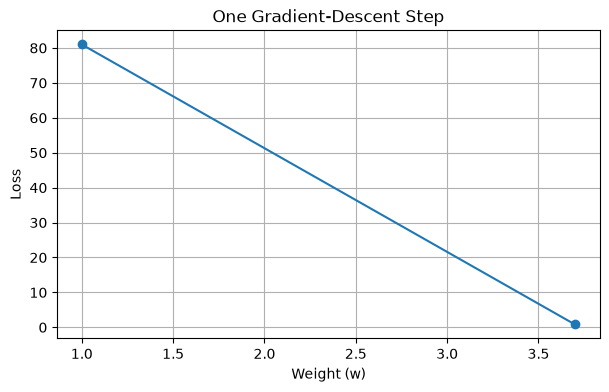

Ended at w = 3.7000, loss = 0.8100


In [10]:
# Plot the one-step descent path
weights = [w, w_new]
losses = [loss, loss_new]

plt.figure(figsize=(7, 4))
plt.plot(weights, losses, marker="o")
plt.xlabel("Weight (w)")
plt.ylabel("Loss")
plt.title("One Gradient-Descent Step")
plt.grid(True)
plt.show()

print(f"Ended at w = {w_new:.4f}, loss = {loss_new:.4f}")


## 7. Reusable Gradient-Descent Function

This function follows the same idea, but repeats the update for multiple iterations.

At every step it:
1. Calculates the prediction.
2. Calculates the loss.
3. Calculates the gradient using the chain rule.
4. Updates the weight.
5. Stores the path.

The stored path lets us visualize how the model moves toward the minimum.


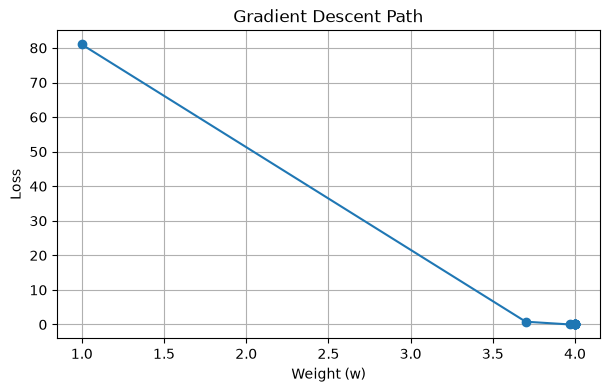

Ended at w = 4.000000
Ended with loss = 0.000000


In [11]:
def gradient_descent(x, target, w_start=1.0, lr=0.05, steps=20):
    w = w_start
    weight_path = []
    loss_path = []

    for _ in range(steps + 1):
        # Forward pass
        a = w * x
        loss = (a - target) ** 2

        # Backward pass
        dloss_da = 2 * (a - target)
        da_dw = x
        gradient = dloss_da * da_dw

        # Save current point
        weight_path.append(w)
        loss_path.append(loss)

        # Update
        w = w - lr * gradient

    return np.array(weight_path), np.array(loss_path)


weight_path, loss_path = gradient_descent(
    x=3.0,
    target=12.0,
    w_start=1.0,
    lr=0.05,
    steps=10
)

plt.figure(figsize=(7, 4))
plt.plot(weight_path, loss_path, marker="o")
plt.xlabel("Weight (w)")
plt.ylabel("Loss")
plt.title("Gradient Descent Path")
plt.grid(True)
plt.show()

print(f"Ended at w = {weight_path[-1]:.6f}")
print(f"Ended with loss = {loss_path[-1]:.6f}")


## 8. Short Answers to the Task Questions

### Why does a negative gradient mean you should increase `w`?

Gradient descent subtracts the gradient:

\[
w_{new}=w-lr\cdot gradient
\]

If the gradient is negative, subtracting it increases `w`. In this example, increasing `w` increases the prediction and reduces the error.

### What stays the same with a million weights?

The core idea stays the same:

\[
	ext{parameter} \leftarrow 	ext{parameter} - lr	imes	ext{gradient}
\]

Backpropagation still uses the chain rule to calculate how the loss changes with respect to each parameter.

### What changes with a million weights?

There are many more parameters and therefore many more gradients to calculate and update. Automatic differentiation/backpropagation makes this practical.

### Why square the error instead of using `(a-target)`?

If we used the raw error, positive and negative errors could cancel each other when there are multiple examples. Squaring makes the loss non-negative and gives larger errors more penalty.

For this simple example:

\[
(3-12)^2=81
\]

The squared loss is also differentiable, giving us a useful gradient for optimization.

---

## Final Result

- Forward prediction: **3**
- Initial loss: **81**
- Analytical gradient: **-54**
- Numerical gradient: **approximately -54**
- Learning rate: **0.05**
- Updated weight: **3.7**
- New loss: **0.81**

